In [ ]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

from competitors import (
    export_benchmark_matrices,
    get_rezaeian_features,
    map_competitor_features,
)
from utils import load_metabric_data

In [ ]:
# Load and Filter for Luminal A
df = load_metabric_data()
df_LumA = df[df['pam50_+_claudin-low_subtype'] == 'LumA'].copy()
df_LumA['target_mortality'] = df_LumA['death_from_cancer'].apply(
    lambda x: 1 if str(x).strip().lower() == 'died of disease' else 0)

Fetching METABRIC dataset from Kaggle...


100%|██████████| 2.72M/2.72M [00:00<00:00, 123MB/s]

Extracting files...


In [ ]:
# Map Competitor Features
rezaeian_list = get_rezaeian_features()
features = map_competitor_features(df_LumA.columns, rezaeian_list)

Mapped 53 features out of the 39 features selected by the competitor.


In [ ]:
X = df_LumA[features]
y = df_LumA['target_mortality']

In [ ]:
# Split & Scale
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# Replicate the Grid Search from original benchmark
models_to_test = {
    'LogisticRegression': (LogisticRegression(max_iter=1000, random_state=42), {
        'C': [0.1, 1, 10], 'class_weight': ['balanced', None]
    }),
    'SVM': (SVC(probability=True, random_state=42), {
        'C': [0.1, 1, 10], 'kernel': ['rbf', 'linear'], 'class_weight': ['balanced', None]
    }),
    'RandomForest': (RandomForestClassifier(random_state=42), {
        'n_estimators': [50, 100, 200], 'max_depth': [3, 5, 10], 'class_weight': ['balanced', None]
    })
}

best_bench_model = None
best_score = 0
winner_name = ""

for name, (model, params) in models_to_test.items():
    grid = GridSearchCV(model, params, cv=5, scoring='roc_auc')
    grid.fit(X_train_scaled, y_train)
    if grid.best_score_ > best_score:
        best_score = grid.best_score_
        best_bench_model = grid.best_estimator_
        winner_name = name

In [ ]:
# Demonstrate WITHOUT tuning
export_benchmark_matrices(best_bench_model, X_test_scaled, y_test,
                          threshold=0.5, suffix=f"{winner_name}_Untuned")

Competitor model (SVM) trained on Rezaeian et al. features.


WITHOUT THRESHOLD TUNING (Default 0.5)
[Untuned_0.5] Average Precision (AP): 0.295
[Untuned_0.5] PR-Optimal Threshold (Max F1): 0.206


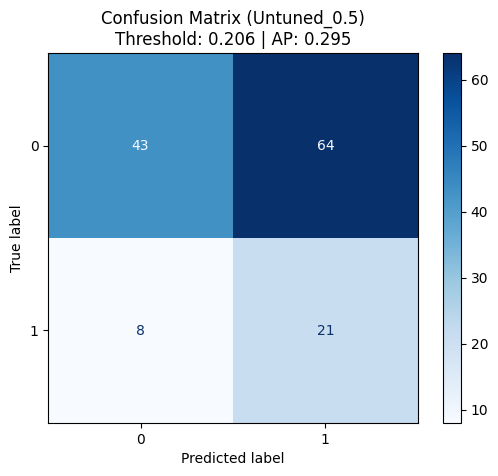

(np.float64(0.2060223892816791), np.float64(0.294991852279259))

In [ ]:
# Demonstrate WITH tuning (PR-Optimal)
export_benchmark_matrices(best_bench_model, X_test_scaled, y_test,
                          threshold=None, suffix=f"{winner_name}_Tuned")
)

WITH THRESHOLD TUNING (Precision-Recall Optimal)
[Tuned_PR_Curve] Average Precision (AP): 0.295
[Tuned_PR_Curve] PR-Optimal Threshold (Max F1): 0.206


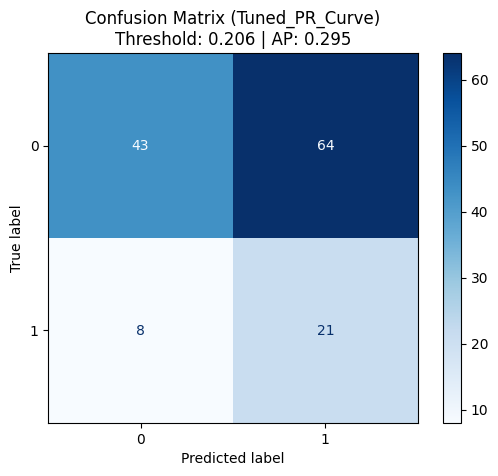

(np.float64(0.2060223892816791), np.float64(0.294991852279259))

In [ ]:
print("WITH THRESHOLD TUNING (Precision-Recall Optimal)")
# The function automatically calculates the best PR threshold if we don't force one
export_benchmark_matrices(
    competitor_model,
    X_test_scaled,
    y_test,
    suffix="Tuned_PR_Curve",
    save_file=False
)